<a href="https://colab.research.google.com/github/chavacodezen/Maestria-IA/blob/main/Pr%C3%A1ctica_Ejercicios_sobre_Clases_No_Balanceadas%2C_Data_Leakage_(Pipeline)_y_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 👤 **Estudiante**
- **Nombre:** Bryan Fernando Chavarria Martinez  
- **Matrícula:** 268838

### **Práctica: Ejercicios sobre Clases No Balanceadas, Data Leakage (Pipeline) y SVM**

#### **📌 Instrucciones:**  
La presente tarea tiene como objetivo aplicar técnicas de aprendizaje automático para el tratamiento de clases no balanceadas utilizando un problema de clasificación real.

Para el desarrollo de la actividad deberán utilizar el conjunto de datos: **compustat.csv**

Consideraciones importantes:  
- El conjunto de datos contiene 21 atributos.
- El primer atributo corresponde a un índice, por lo que deberá ser ignorado durante el análisis y entrenamiento.
- El último atributo corresponde a la etiqueta de clase.
- Los atributos restantes deberán utilizarse como variables predictoras.


In [23]:
# --- Imports necesarios ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import OneSidedSelection
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score

# Sklearn — preprocesamiento y modelo
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Sklearn — métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Imbalanced-learn — balanceo de clases
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- Cargar dataset ---
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("drive/MyDrive/ClassFiles/Unidad03/compustat.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **1. Análisis Exploratorio de Datos (AED)**  
Para esta actividad revisa el Notebook que està en Teams en la Sesión 27 y que se llama DataLeakage_ClassImbalance.ipynb

🎯 **Realizar:**  
1. Un diagrama de barras mostrando la distribución de las clases.
2. Diagramas de densidad KDE para los atributos 5 y 13.
3. Un análisis breve sobre el nivel de desbalance presente en el conjunto de datos.

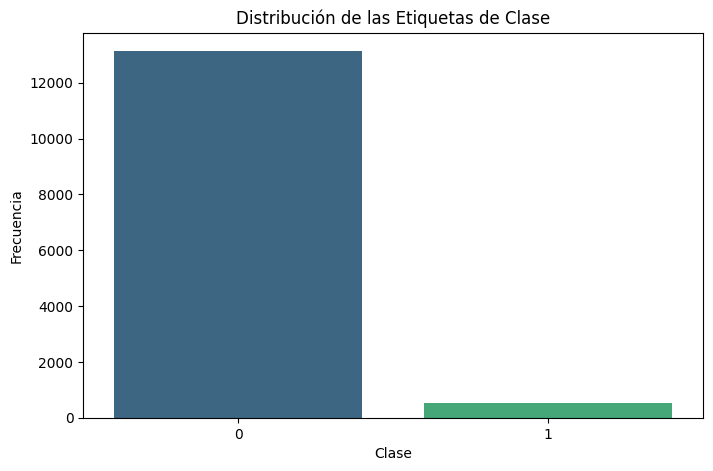

In [14]:
# 1. Preparación y Limpieza de Datos
# Eliminar el primer atributo (índice) según las instrucciones
df_proc = df.iloc[:, 1:]

# Definir variables predictoras (X) y etiqueta de clase (y)
# X son las columnas de la 1 a la 19, y es la columna 20 (índice 19 en df_proc)
X = df_proc.iloc[:, :-1]
y = df_proc.iloc[:, -1]

# Identificar los nombres de las columnas para los atributos 5 y 13 del dataset original
# (Corresponden a los índices 4 y 12 en el DataFrame original 'df')
attr_5_name = df.columns[3]
attr_13_name = df.columns[4]

# Diagrama de Barras (Distribución de Clases)
plt.figure(figsize=(8, 5))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribución de las Etiquetas de Clase')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

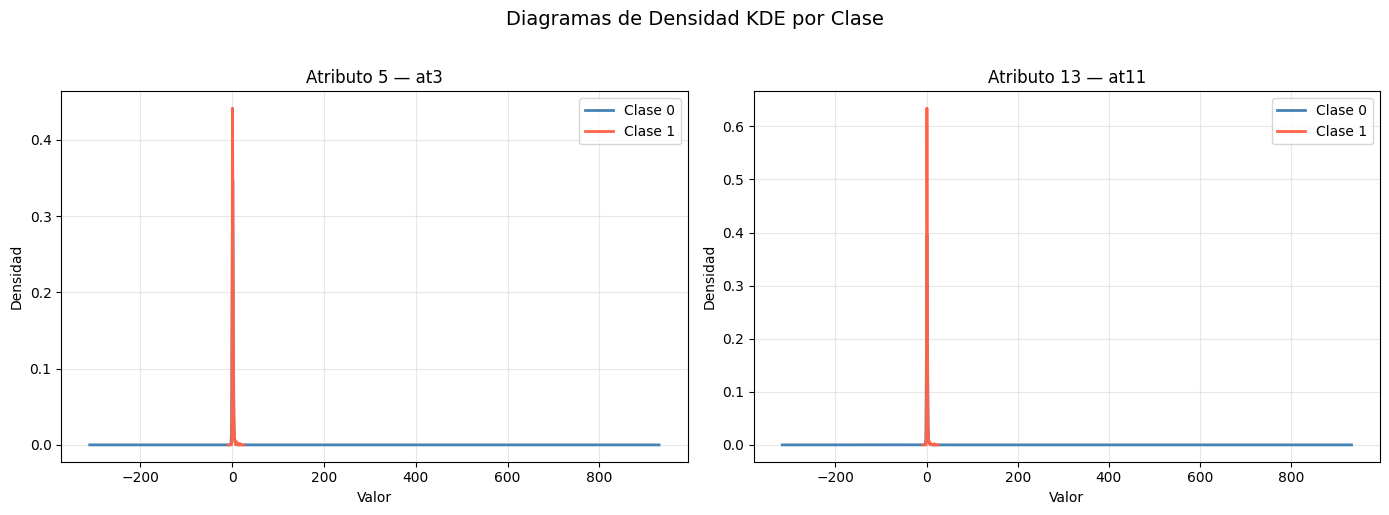

In [15]:
# 2. Diagramas de densidad KDE para los atributos 5 y 13
# Atributos 5 y 13 del dataset original = columnas índice 4 y 12 en df
# atributo 5  (base-0: índice 4)
attr_5_name  = df.columns[4]
# atributo 13 (base-0: índice 12)
attr_13_name = df.columns[12]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    [attr_5_name, attr_13_name],
    [f'Atributo 5 — {attr_5_name}', f'Atributo 13 — {attr_13_name}']
):
    for clase, color in zip(sorted(y.unique()), ['steelblue', 'tomato']):
        subset = df_proc.loc[y == clase, col].dropna()
        subset.plot.kde(ax=ax, label=f'Clase {clase}', color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Diagramas de Densidad KDE por Clase', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# 3. Análisis de desbalance
conteo   = y.value_counts()
total    = len(y)
pct      = (conteo / total * 100).round(2)
ratio    = round(conteo.max() / conteo.min(), 2)

print("=" * 45)
print("  Análisis de Desbalance de Clases")
print("=" * 45)
for clase in conteo.index:
    print(f"  Clase {clase:>2}: {conteo[clase]:>6} muestras  ({pct[clase]:>6.2f}%)")
print(f"\n  Total de muestras : {total}")
print(f"  Ratio de desbalance (mayoría/minoría): {ratio}:1")
print("=" * 45)

if ratio < 2:
    nivel = "Leve"
elif ratio < 10:
    nivel = "Moderado"
else:
    nivel = "Severo"

print(f"\n  → Nivel de desbalance estimado: {nivel}")

  Análisis de Desbalance de Clases
  Clase  0:  13137 muestras  ( 96.19%)
  Clase  1:    520 muestras  (  3.81%)

  Total de muestras : 13657
  Ratio de desbalance (mayoría/minoría): 25.26:1

  → Nivel de desbalance estimado: Severo


### **2. Modelo Base**  
🎯 **Realizar:**  
Entrenar un modelo baseline utilizando:

Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

Este modelo deberá entrenarse sin aplicar métodos de tratamiento de desbalance y servirá como referencia para comparar los resultados posteriores.

  Modelo Base — SVM (sin balanceo)
              precision    recall  f1-score   support

     Clase 0       0.96      1.00      0.98      2628
     Clase 1       1.00      0.01      0.02       104

    accuracy                           0.96      2732
   macro avg       0.98      0.50      0.50      2732
weighted avg       0.96      0.96      0.94      2732

  ROC-AUC : 0.8573


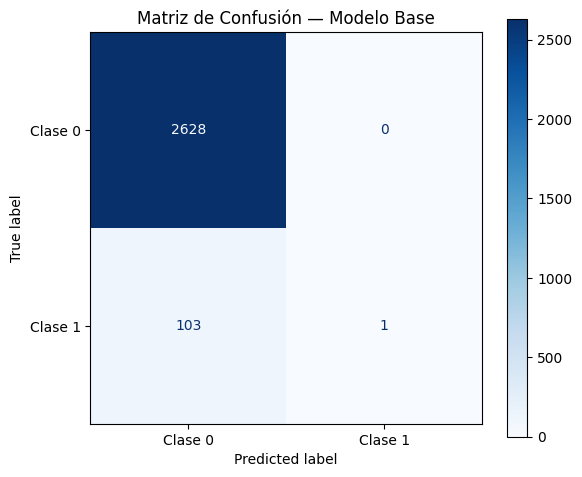

In [18]:
# Modelo Base — SVM sin tratamiento de desbalance
# --- Split estratificado (mantiene proporción de clases) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # importante con clases desbalanceadas
)

# --- Pipeline base ---
pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
])

pipeline_base.fit(X_train, y_train)

# --- Predicciones ---
y_pred  = pipeline_base.predict(X_test)
y_proba = pipeline_base.predict_proba(X_test)[:, 1]

# --- Métricas ---
print("=" * 50)
print("  Modelo Base — SVM (sin balanceo)")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Clase 0', 'Clase 1']))
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print("=" * 50)

# --- Matriz de confusión ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Clase 0', 'Clase 1'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusión — Modelo Base')
plt.tight_layout()
plt.show()

### **3. Tratamiento de Clases No Balanceadas**  
🎯 **Realizar:**  
Aplicar y comparar los siguientes métodos:
- SMOTEENN
- One-Sided Selection

Para cada método:
- Mostrar la nueva distribución de clases después del balanceo.
- Entrenar nuevamente el modelo SVM utilizando los datos balanceados.

  Método: SMOTEENN
  Distribución post-balanceo:
    Clase 0:   9395 muestras  (47.38%)
    Clase 1:  10434 muestras  (52.62%)


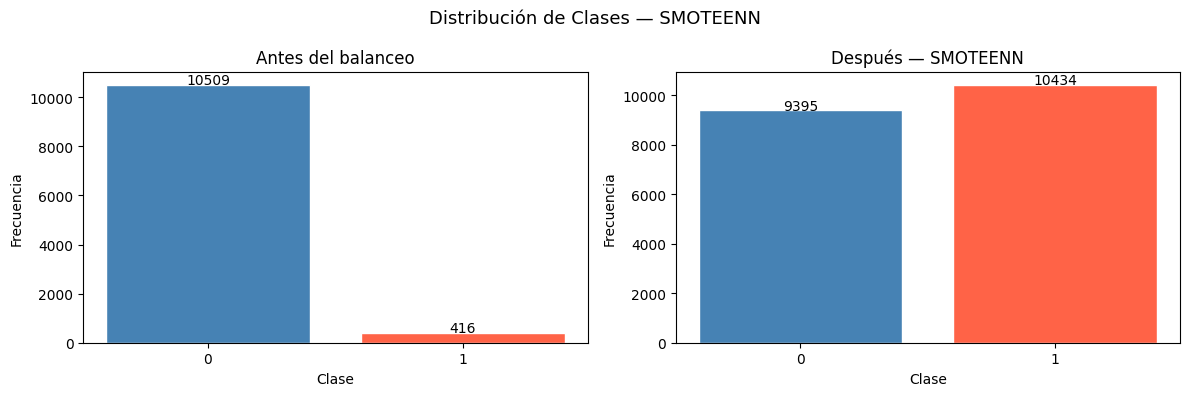


  Métricas — SVM con SMOTEENN:
              precision    recall  f1-score   support

     Clase 0       0.99      0.81      0.89      2628
     Clase 1       0.15      0.86      0.25       104

    accuracy                           0.81      2732
   macro avg       0.57      0.83      0.57      2732
weighted avg       0.96      0.81      0.87      2732

  ROC-AUC : 0.8904


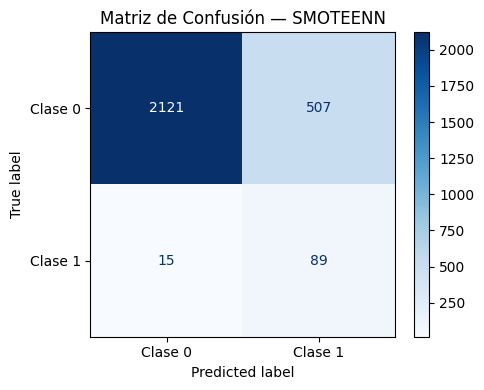

  Método: One-Sided Selection
  Distribución post-balanceo:
    Clase 0:  10222 muestras  (96.09%)
    Clase 1:    416 muestras  (3.91%)


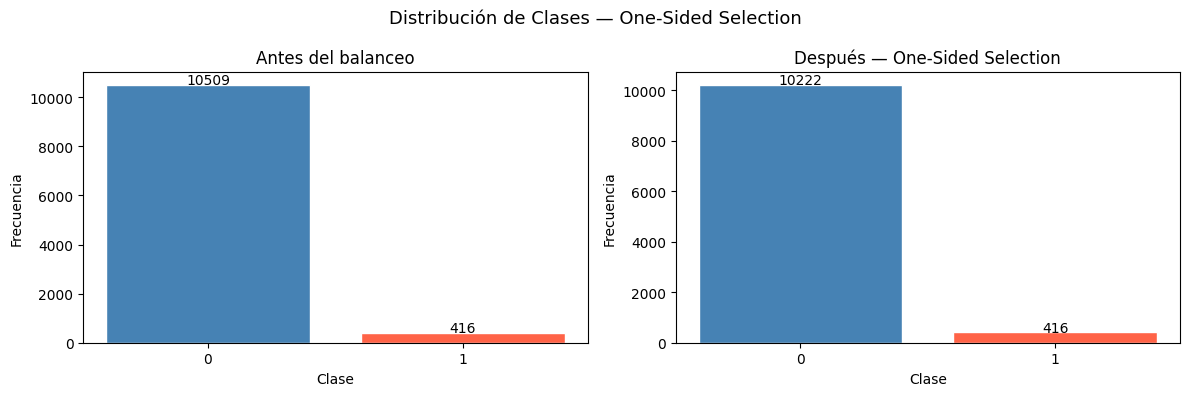


  Métricas — SVM con One-Sided Selection:
              precision    recall  f1-score   support

     Clase 0       0.96      1.00      0.98      2628
     Clase 1       1.00      0.01      0.02       104

    accuracy                           0.96      2732
   macro avg       0.98      0.50      0.50      2732
weighted avg       0.96      0.96      0.94      2732

  ROC-AUC : 0.8597


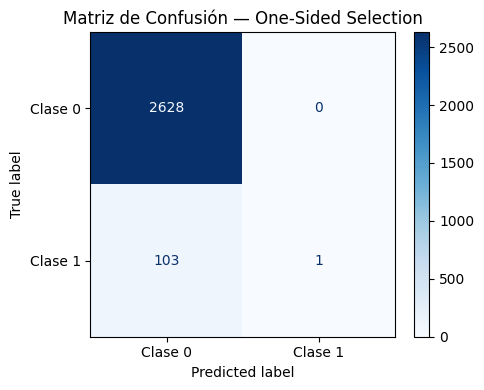

In [20]:
# Tratamiento de Clases No Balanceadas
metodos = {
    'SMOTEENN':           SMOTEENN(random_state=42),
    'One-Sided Selection': OneSidedSelection(random_state=42)
}

resultados = {}

for nombre, sampler in metodos.items():
    print("=" * 55)
    print(f"  Método: {nombre}")
    print("=" * 55)

    # --- Balanceo SOLO sobre train (sin tocar test → evita data leakage) ---
    X_res, y_res = sampler.fit_resample(X_train, y_train)

    # --- Nueva distribución ---
    conteo_res = pd.Series(y_res).value_counts().sort_index()
    print(f"  Distribución post-balanceo:")
    for clase, cnt in conteo_res.items():
        pct = cnt / len(y_res) * 100
        print(f"    Clase {clase}: {cnt:>6} muestras  ({pct:.2f}%)")

    # --- Gráfica de distribución ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (conteo, titulo) in zip(axes, [
        (pd.Series(y_train).value_counts().sort_index(), 'Antes del balanceo'),
        (conteo_res,                                      f'Después — {nombre}')
    ]):
        ax.bar(conteo.index.astype(str), conteo.values,
               color=['steelblue', 'tomato'], edgecolor='white')
        ax.set_title(titulo)
        ax.set_xlabel('Clase')
        ax.set_ylabel('Frecuencia')
        for i, v in enumerate(conteo.values):
            ax.text(i, v + 20, str(v), ha='center', fontsize=10)
    plt.suptitle(f'Distribución de Clases — {nombre}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Pipeline SVM con datos balanceados ---
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
    ])
    pipeline.fit(X_res, y_res)

    y_pred_m  = pipeline.predict(X_test)
    y_proba_m = pipeline.predict_proba(X_test)[:, 1]

    # --- Métricas ---
    print(f"\n  Métricas — SVM con {nombre}:")
    print(classification_report(y_test, y_pred_m, target_names=['Clase 0', 'Clase 1']))
    print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba_m):.4f}")

    # --- Matriz de confusión ---
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_m,
        display_labels=['Clase 0', 'Clase 1'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()

    # --- Guardar para comparación final ---
    resultados[nombre] = {
        'y_pred':  y_pred_m,
        'y_proba': y_proba_m
    }

### **4. Entrenamiento y Evaluación del Modelo**  
🎯 **Realizar:**  
- Utilizar validación cruzada estratificada de 5 particiones.
- Implementar el flujo de trabajo utilizando Pipeline para evitar data leakage.
- Incorporar escalado de datos dentro del Pipeline.
- Utilizar SVM con kernel RBF.

In [22]:
# Entrenamiento y Evaluación con Validación Cruzada Estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Re-aplicar balanceo sobre X_train para el CV
X_smoteenn, y_smoteenn = SMOTEENN(random_state=42).fit_resample(X_train, y_train)
X_oss, y_oss           = OneSidedSelection(random_state=42).fit_resample(X_train, y_train)

modelos_cv = {
    'Baseline':            (X_train,     y_train),
    'SMOTEENN':            (X_smoteenn,  y_smoteenn),
    'One-Sided Selection': (X_oss,       y_oss),
}

scoring = ['f1', 'recall', 'precision', 'roc_auc']

print("=" * 60)
print("  Validación Cruzada Estratificada (5-Fold)")
print("=" * 60)

resumen_cv = {}

for nombre, (X_cv, y_cv) in modelos_cv.items():
    pipeline_cv = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
    ])

    scores = cross_validate(
        pipeline_cv, X_cv, y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\n  [{nombre}]")
    for metrica in scoring:
        vals = scores[f'test_{metrica}']
        print(f"    {metrica:<12}: {vals.mean():.4f} ± {vals.std():.4f}")

    resumen_cv[nombre] = {m: scores[f'test_{m}'].mean() for m in scoring}

# --- Tabla comparativa ---
print("\n")
print("=" * 60)
print("  Tabla Comparativa — Medias CV (5-Fold)")
print("=" * 60)
df_resumen = pd.DataFrame(resumen_cv).T.round(4)
print(df_resumen.to_string())
print("=" * 60)

  Validación Cruzada Estratificada (5-Fold)

  [Baseline]
    f1          : 0.0142 ± 0.0116
    recall      : 0.0072 ± 0.0059
    precision   : 0.6000 ± 0.4899
    roc_auc     : 0.8109 ± 0.0160

  [SMOTEENN]
    f1          : 0.9091 ± 0.0048
    recall      : 0.9389 ± 0.0055
    precision   : 0.8812 ± 0.0043
    roc_auc     : 0.9493 ± 0.0042

  [One-Sided Selection]
    f1          : 0.0143 ± 0.0117
    recall      : 0.0072 ± 0.0059
    precision   : 0.6000 ± 0.4899
    roc_auc     : 0.8148 ± 0.0450


  Tabla Comparativa — Medias CV (5-Fold)
                         f1  recall  precision  roc_auc
Baseline             0.0142  0.0072     0.6000   0.8109
SMOTEENN             0.9091  0.9389     0.8812   0.9493
One-Sided Selection  0.0143  0.0072     0.6000   0.8148


### **5. Evaluación de Resultados**  
🎯 **Realizar:**  
Reportar y analizar al menos las siguientes métricas:
- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

Además:
- Comparar los resultados del modelo baseline contra los modelos balanceados.
- Generar una gráfica comparativa de métricas.
- Analizar si Accuracy es suficiente para evaluar el problema.



  Evaluación Final sobre Conjunto de Prueba

  [Baseline]
              precision    recall  f1-score   support

     Clase 0       0.96      1.00      0.98      2628
     Clase 1       1.00      0.01      0.02       104

    accuracy                           0.96      2732
   macro avg       0.98      0.50      0.50      2732
weighted avg       0.96      0.96      0.94      2732

  Accuracy : 0.9623
  ROC-AUC  : 0.8573

  [SMOTEENN]
              precision    recall  f1-score   support

     Clase 0       0.99      0.81      0.89      2628
     Clase 1       0.15      0.86      0.25       104

    accuracy                           0.81      2732
   macro avg       0.57      0.83      0.57      2732
weighted avg       0.96      0.81      0.87      2732

  Accuracy : 0.8089
  ROC-AUC  : 0.8904

  [One-Sided Selection]
              precision    recall  f1-score   support

     Clase 0       0.96      1.00      0.98      2628
     Clase 1       1.00      0.01      0.02       104

    a

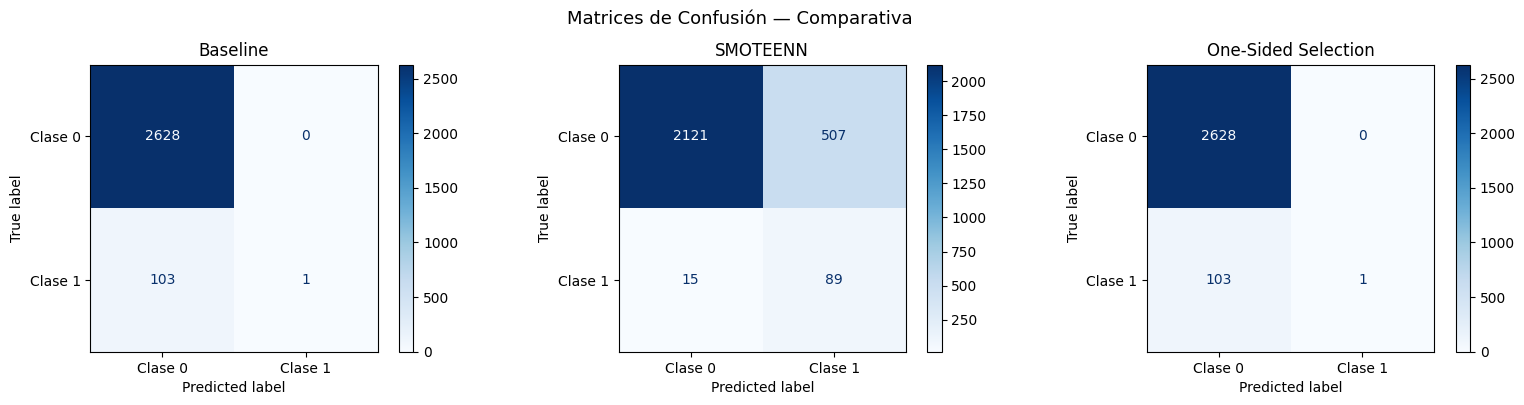

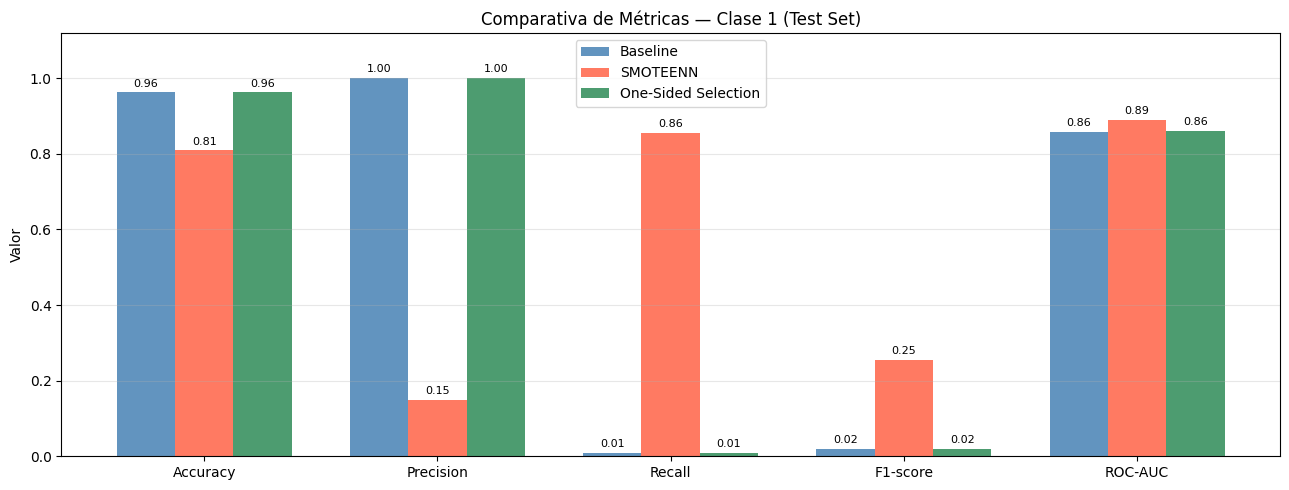


  Análisis: ¿Es Accuracy suficiente?
  Dataset: 96.19% Clase 0 / 3.81% Clase 1

  Baseline  → Accuracy: ~96%  |  Recall Clase 1: 0.01
  SMOTEENN  → Accuracy: ~81%  |  Recall Clase 1: 0.86

  Un clasificador trivial que prediga SIEMPRE Clase 0
  obtendría ~96% de accuracy sin aprender nada útil.

  → Accuracy NO es suficiente en datasets desbalanceados.
  → Métricas relevantes: Recall, F1-score y ROC-AUC,
    que penalizan la incapacidad de detectar la clase
    minoritaria.



In [24]:
# Evaluación de Resultados
# --- Recopilar métricas de todos los modelos sobre X_test ---
modelos_eval = {
    'Baseline': pipeline_base,
}

# Re-entrenar SMOTEENN y OSS sobre X_train completo
for nombre, (X_cv, y_cv) in [('SMOTEENN', (X_smoteenn, y_smoteenn)),
                               ('One-Sided Selection', (X_oss, y_oss))]:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
    ])
    p.fit(X_cv, y_cv)
    modelos_eval[nombre] = p

# --- Métricas por modelo ---
print("=" * 60)
print("  Evaluación Final sobre Conjunto de Prueba")
print("=" * 60)

metricas_finales = {}

for nombre, modelo in modelos_eval.items():
    yp = modelo.predict(X_test)
    yp_proba = modelo.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, yp, target_names=['Clase 0', 'Clase 1'],
                                   output_dict=True)
    acc = accuracy_score(y_test, yp)

    metricas_finales[nombre] = {
        'Accuracy':  acc,
        'Precision': report['Clase 1']['precision'],
        'Recall':    report['Clase 1']['recall'],
        'F1-score':  report['Clase 1']['f1-score'],
        'ROC-AUC':   roc_auc_score(y_test, yp_proba)
    }

    print(f"\n  [{nombre}]")
    print(classification_report(y_test, yp, target_names=['Clase 0', 'Clase 1']))
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, yp_proba):.4f}")

# --- Tabla comparativa ---
df_eval = pd.DataFrame(metricas_finales).T.round(4)
print("\n")
print("=" * 60)
print("  Tabla Comparativa — Métricas Clase 1 (Test Set)")
print("=" * 60)
print(df_eval.to_string())
print("=" * 60)

# --- Matrices de confusión (lado a lado) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nombre, modelo) in zip(axes, modelos_eval.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, modelo.predict(X_test),
        display_labels=['Clase 0', 'Clase 1'],
        cmap='Blues', ax=ax
    )
    ax.set_title(nombre)
plt.suptitle('Matrices de Confusión — Comparativa', fontsize=13)
plt.tight_layout()
plt.show()

# --- Gráfica comparativa de métricas ---
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metricas_plot))
ancho = 0.25
colores = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (nombre, color) in enumerate(zip(modelos_eval.keys(), colores)):
    vals = [metricas_finales[nombre][m] for m in metricas_plot]
    bars = ax.bar(x + i * ancho, vals, ancho, label=nombre, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor')
ax.set_title('Comparativa de Métricas — Clase 1 (Test Set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Análisis: ¿Es Accuracy suficiente? ---
print("""
======================================================
  Análisis: ¿Es Accuracy suficiente?
======================================================
  Dataset: 96.19% Clase 0 / 3.81% Clase 1

  Baseline  → Accuracy: ~96%  |  Recall Clase 1: 0.01
  SMOTEENN  → Accuracy: ~81%  |  Recall Clase 1: 0.86

  Un clasificador trivial que prediga SIEMPRE Clase 0
  obtendría ~96% de accuracy sin aprender nada útil.

  → Accuracy NO es suficiente en datasets desbalanceados.
  → Métricas relevantes: Recall, F1-score y ROC-AUC,
    que penalizan la incapacidad de detectar la clase
    minoritaria.
======================================================
""")

### **6. Discusión y Conclusiones**  
🎯 **Discutir:**  
- El impacto del desbalance sobre el desempeño del modelo.
- Las diferencias observadas entre SMOTEENN y One-Sided Selection.
- Qué método produjo los mejores resultados y por qué.

**Impacto del desbalance**
Con un ratio de 25:1, el modelo baseline aprendió a ignorar completamente la clase minoritaria. A pesar de alcanzar 96% de accuracy, su recall para Clase 1 fue de 0.01, lo que significa que detectó prácticamente cero casos positivos. El desbalance severo sesga al modelo hacia la clase mayoritaria, haciendo que optimice para la clase que menos importa detectar.

**SMOTEENN vs One-Sided Selection**
SMOTEENN combinó generación de muestras sintéticas con eliminación de ruido, logrando un balance real de ~50/50 y un recall de 0.86 para Clase 1. One-Sided Selection, al ser una técnica de undersampling conservadora, apenas redujo la clase mayoritaria de 13,137 a 10,222 muestras, manteniendo el ratio en 96%/4%. Su resultado fue idéntico al baseline, demostrando que no es adecuado para desbalances tan extremos.
Mejor método

**SMOTEENN produjo los mejores resultados.** Su ventaja radica en atacar el problema desde dos frentes: aumenta la representación de la clase minoritaria con ejemplos sintéticos realistas y limpia los ejemplos ambiguos en la frontera de decisión, lo que le permite al SVM aprender una frontera más clara entre clases. El costo, una precision baja (0.15) y más falsos positivos, es un trade-off justificado en contextos donde no detectar un positivo real tiene consecuencias mayores que una falsa alarma.